## Checking grids memory filling being friendly to cache

Expected value: 31.026666666666667


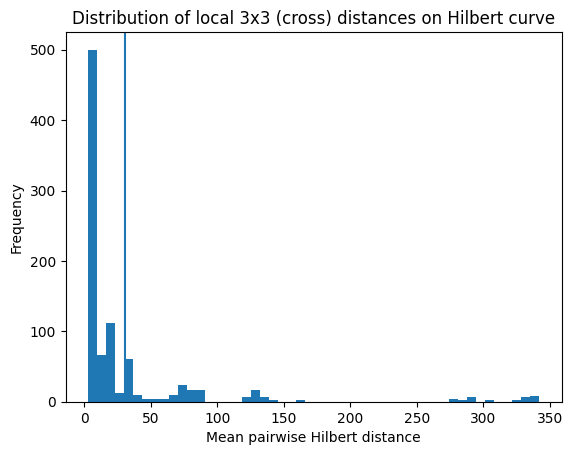

In [1]:
import matplotlib.pyplot as plt


def hilbert_index(x, y, n):
    d = 0
    s = n // 2
    while s > 0:
        rx = 1 if (x & s) else 0
        ry = 1 if (y & s) else 0
        d += s * s * ((3 * rx) ^ ry)
        if ry == 0:
            if rx == 1:
                x = n - 1 - x
                y = n - 1 - y
            x, y = y, x
        s //= 2
    return d


N = 32

H = [[hilbert_index(x, y, N) for x in range(N)] for y in range(N)]

distances = []

for y in range(1, N - 1):
    for x in range(1, N - 1):
        pts = [(x, y), (x - 1, y), (x + 1, y), (x, y - 1), (x, y + 1)]
        idx = [H[py][px] for px, py in pts]
        s = 0
        c = 0
        for i in range(len(idx)):
            for j in range(i + 1, len(idx)):
                s += abs(idx[i] - idx[j])
                c += 1
        distances.append(s / c)

# expected value
E = sum(distances) / len(distances)
print("Expected value:", E)

plt.figure()
plt.hist(distances, bins=50)
plt.axvline(E)
plt.xlabel("Mean pairwise Hilbert distance")
plt.ylabel("Frequency")
plt.title("Distribution of local 3x3 (cross) distances on Hilbert curve")
plt.show()

Expected value: 26.0


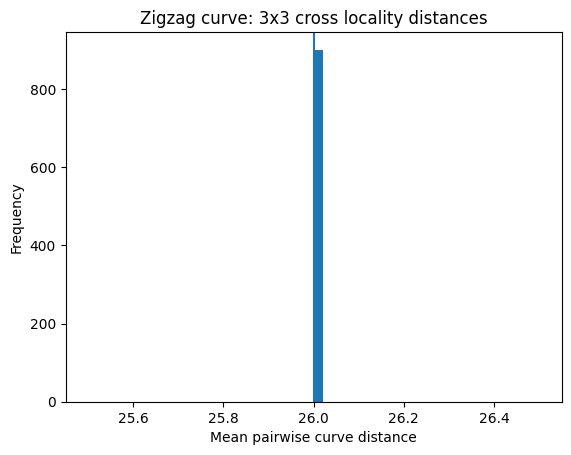

In [4]:
import matplotlib.pyplot as plt


# zigzag index
def zigzag_index(x, y, n):
    if y % 2 == 0:
        return y * n + x
    else:
        return y * n + (n - 1 - x)


N = 32

H = [[zigzag_index(x, y, N) for x in range(N)] for y in range(N)]

distances = []

for y in range(1, N - 1):
    for x in range(1, N - 1):
        pts = [(x, y), (x - 1, y), (x + 1, y), (x, y - 1), (x, y + 1)]
        idx = [H[py][px] for px, py in pts]

        s = 0
        c = 0
        for i in range(len(idx)):
            for j in range(i + 1, len(idx)):
                s += abs(idx[i] - idx[j])
                c += 1
        distances.append(s / c)

# expected value
E = sum(distances) / len(distances)
print("Expected value:", E)

plt.figure()
plt.hist(distances, bins=50)
plt.axvline(E)
plt.xlabel("Mean pairwise curve distance")
plt.ylabel("Frequency")
plt.title("Zigzag curve: 3x3 cross locality distances")
plt.show()

Expected value (Gosper 7-hex mean distance): 19.80952380952381


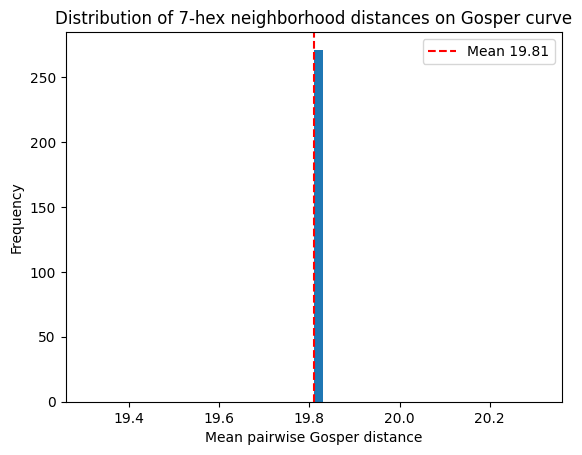

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# Axial coordinates for hex grid neighbors (pointy-top orientation)
hex_directions = [(1, 0), (1, -1), (0, -1), (-1, 0), (-1, 1), (0, 1)]


def gosper_index(q, r, size):
    """
    Simple integer index mapping for a Gosper-like hex curve.
    size: approximate "radius" of the hex grid
    This is a heuristic: converts (q,r) to a 1D index along a Hilbert-like traversal.
    """
    # Using a simple row-major traversal in axial coordinates as approximation
    return (r + size) * (2 * size + 1) + (q + size)


# Parameters
size = 10  # radius of hex grid (from center 0,0)
grid_points = [
    (q, r)
    for r in range(-size, size + 1)
    for q in range(-size, size + 1)
    if -size <= -q - r <= size
]

# Build index map
H = {pt: gosper_index(*pt, size) for pt in grid_points}

# Collect mean distances for 7-point hex windows
distances = []

for q, r in grid_points:
    # 7-point hex neighborhood
    pts = [(q, r)] + [
        (q + dq, r + dr) for dq, dr in hex_directions if (q + dq, r + dr) in H
    ]
    if len(pts) != 7:
        continue  # skip incomplete neighborhoods at edges
    idx = [H[pt] for pt in pts]
    s = 0
    c = 0
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):
            s += abs(idx[i] - idx[j])
            c += 1
    distances.append(s / c)

distances = np.array(distances)
E = distances.mean()
print("Expected value (Gosper 7-hex mean distance):", E)

# Plot distribution
plt.figure()
plt.hist(distances, bins=50)
plt.axvline(E, color="red", linestyle="dashed", label=f"Mean {E:.2f}")
plt.xlabel("Mean pairwise Gosper distance")
plt.ylabel("Frequency")
plt.title("Distribution of 7-hex neighborhood distances on Gosper curve")
plt.legend()
plt.show()

In [ ]:
distances = []
for q, r in grid_points:
    pts = [(q, r)] + [
        (q + dq, r + dr) for dq, dr in hex_directions if (q + dq, r + dr) in H
    ]
    if len(pts) != 7:
        continue
    idx = [H[pt] for pt in pts]
    s = 0
    c = 0
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):
            s += abs(idx[i] - idx[j])
            c += 1
    distances.append(s / c)

distances = np.array(distances)
E = distances.mean()
E  # double check for gosper curve expected value

np.float64(19.80952380952381)